# EDA - Ensino Medio

**Living Stone Foundation - Applied Data Lab**

**Audience:** non-authors of the project.
**Level in focus:** **Ensino Medio** (`medio`).
**Question this notebook answers:** What does official school dropout look like, where is it higher, and which school characteristics - including the school's *own dropout history* - move together with it?


## Variable dictionary (read before the charts)

| Column / label in charts | Plain-English meaning | How to read values |
|---|---|---|
| `target_dropout_rate` / **Dropout rate (%)** | Official INEP "taxa de abandono": share of students who **stopped attending** during the school year, after the Census reference date | 0 = nobody left; 5 = 5% left. Higher = worse |
| `year` | School Census / attainment-rate year | Years present in the mart (currently 2018-2025) |
| `school_id` (`CO_ENTIDADE`) | Unique school code (INEP) | Join key between Census and attainment-rate data |
| `state_code` | Brazilian state abbreviation ("UF" = Unidade Federativa) | e.g. SP, BA, AM |
| `municipality_id` | IBGE municipality code | Geographic context |
| `admin_dependency_type` | Administrative network | 1=Federal, 2=State, 3=Municipal, 4=Private |
| `location_type` | School location type | 1=Urban, 2=Rural |
| `is_rural` | 1 if rural school | Shortcut of `location_type == 2` |
| `is_public` | 1 if public network (federal/state/municipal) | 0 = private |
| `has_water` | Has potable / public water | 1=yes, 0=no |
| `has_electricity` | Connected to public electricity | 1=yes, 0=no |
| `has_sewage` | Public sewage connection | 1=yes, 0=no |
| `has_internet` / `has_internet_for_students` | Internet at school / specifically available to students | 1=yes, 0=no |
| `has_library` | Library / reading room | 1=yes, 0=no |
| `has_computer_lab` | Computer lab | 1=yes, 0=no |
| `has_sports_court` | Sports court | 1=yes, 0=no |
| `enrollment_basic_ed` | Enrollment count (basic education total, when available) | Larger = bigger school |
| `enrollment_level` | Enrollment used for this level (Fundamental or Medio) | Filter requires >= 20 students |
| `teacher_count_basic_ed` | Number of teachers (basic education) | Staffing intensity |
| `student_teacher_ratio` | Students / teachers | Higher often means more crowded classes |
| `avg_class_size` | Enrollment / number of classes for this level | Higher = larger classes |
| `overage_enrollment_share` | Share of students above the expected age for this level | A known proxy for grade-age distortion, itself a dropout correlate |
| `dropout_rate_lag1` / `_lag2` | This school's own dropout rate 1 / 2 years earlier | Missing (NaN) for a school's first year in the panel |
| `dropout_rate_3yr_avg` / `_trend` | Trailing 3-year average / (lag1 - lag2) | Trend > 0 means the rate has been rising |
| `has_history` | 1 if the school has at least one prior year on record | 0 = first appearance in the 2018-2025 window |
| `approval_rate_lag1` / `failure_rate_lag1` | This school's own approval / grade-repetition rate, prior year | A rising failure rate is a known leading indicator of dropout |
| `municipal_dropout_rate_lag1` / `state_dropout_rate_lag1` | Average dropout rate across the municipality / state, prior year | A spatial-lag signal for local shocks a single school's history cannot capture |
| `is_covid_year` | 1 for school years 2020-2021 | INEP suspended normal grade-progression rules in these years |
| `risk_band` | low / moderate / high | Relative triage label inside the level |
| `high_risk` | 1 if school is in the elevated-risk group | Binary flag used for the triage/ranking metrics |
| **MAE / RMSE / R2** | Model error metrics (later notebooks / model folder) | Lower MAE/RMSE better; R2 closer to 1 better |

### Acronyms
| Acronym | Meaning |
|---|---|
| **INEP** | Brazil's federal education-statistics agency |
| **School Census** ("Censo Escolar") | Annual school census (structure + enrollment) |
| **School Attainment Rates** ("Taxas de Rendimento") | Official approval / failure / dropout rates |
| **EDA** | Exploratory Data Analysis |
| **UF** | Unidade Federativa (Brazilian state) |
| **Fundamental** | Ensino Fundamental: grades 1-9, roughly ages 6-14 |
| **Medio** | Ensino Medio: grades 10-12, Brazil's upper-secondary stage |
| **EJA** | Educacao de Jovens e Adultos (adult / youth education track) |


In [1]:
# Cell A - project path only (no Path.cwd / exists / resolve)
import sys
ROOT = r"C:\Users\User\Desktop\Projeto Living Stone Foundation"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


### What this cell did
Added the project folder to Python's import path using a **fixed string** (no `Path.cwd()` / `exists` / `resolve`). Those path checks can freeze kernels on Desktop/OneDrive.


In [2]:
# Cell B - imports (first run can take a minute for pandas/seaborn)
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

FEATURE_LABELS = {
    "is_rural": "Rural school (1=yes)",
    "is_public": "Public network (1=yes)",
    "has_internet": "Has internet (1=yes)",
    "has_internet_for_students": "Has internet for students (1=yes)",
    "has_computer_lab": "Has computer lab (1=yes)",
    "has_sports_court": "Has sports court (1=yes)",
    "has_library": "Has library (1=yes)",
    "has_water": "Has water (1=yes)",
    "has_electricity": "Has electricity (1=yes)",
    "has_sewage": "Has sewage (1=yes)",
    "enrollment_level": "Enrollment (this level)",
    "enrollment_basic_ed": "Basic-ed enrollment (total)",
    "teacher_count_basic_ed": "Number of teachers",
    "student_teacher_ratio": "Students per teacher",
    "avg_class_size": "Average class size",
    "overage_enrollment_share": "Share of over-age students",
    "admin_dependency_type": "Admin network code",
    "location_type": "Urban/rural code",
    "target_dropout_rate": "Dropout rate (%)",
    "dropout_rate_lag1": "Dropout rate, prior year",
    "dropout_rate_lag2": "Dropout rate, 2 years prior",
    "dropout_rate_3yr_avg": "Dropout rate, 3-year trailing avg",
    "dropout_rate_trend": "Dropout rate trend",
    "approval_rate_lag1": "Approval rate, prior year",
    "failure_rate_lag1": "Failure rate, prior year",
    "municipal_dropout_rate_lag1": "Municipality's dropout rate, prior year",
    "state_dropout_rate_lag1": "State's dropout rate, prior year",
}
from src.eda import load_level_mart, missingness_table, summary_by_state
print("Imports OK")


Imports OK


### What this cell did
Loaded charting/table libraries. The **first** run can take ~30-90s while pandas/seaborn warm up - that is normal, not a freeze on `import sys`.


In [3]:
df = load_level_mart('medio')
print('Rows (school x year):', df.shape[0])
print('Columns:', df.shape[1])
print('Unique schools:', df['school_id'].nunique())
print('Years:', sorted(df['year'].dropna().astype(int).unique().tolist()))
display(df.head())


Rows (school x year): 225199
Columns: 57
Unique schools: 32612
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,year,school_id,state_code,municipality_id,admin_dependency_type,location_type,operating_status_type,has_water,has_electricity,electricity_absent,has_sewage,sewage_absent,has_internet,has_internet_for_students,has_library,has_computer_lab,has_sports_court,enrollment_basic_ed,enrollment_fundamental,enrollment_medio,...,dropout_rate_lag2,dropout_rate_3yr_avg,dropout_rate_trend,has_history,approval_rate_lag1,failure_rate_lag1,municipal_dropout_rate_lag1,state_dropout_rate_lag1,enrollment_level,student_teacher_ratio,avg_class_size,overage_enrollment_share,eja_enrollment_share,is_covid_year,target_definition,education_level,country_iso3,risk_band,high_risk,quality_flag
0,2018,11024968,RO,1100015,2,1,1,0,1,0,0,0,1,0,1,1,1,155.000,0.000,155.000,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,155.000,11.071,22.143,0.974,0.000,0,inep_official_dropout_rate,medio,BRA,low,0,ok
1,2018,11025638,RO,1100015,2,1,1,0,1,0,0,0,1,0,1,1,1,"1,142.000",565.000,577.000,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,577.000,8.243,16.486,0.626,0.000,0,inep_official_dropout_rate,medio,BRA,high,1,ok
2,2018,11006773,RO,1100023,2,1,1,0,1,0,0,0,1,0,1,1,1,"2,013.000","1,120.000",413.000,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,413.000,7.000,31.769,0.487,0.238,0,inep_official_dropout_rate,medio,BRA,high,1,ok
3,2018,11006889,RO,1100023,2,1,1,0,1,0,0,0,1,0,0,0,1,"1,436.000",770.000,666.000,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,666.000,14.800,30.273,0.576,0.000,0,inep_official_dropout_rate,medio,BRA,high,1,ok
4,2018,11007168,RO,1100023,2,1,1,0,1,0,0,0,1,0,1,1,1,662.000,509.000,153.000,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,153.000,6.955,25.500,0.364,0.000,0,inep_official_dropout_rate,medio,BRA,high,1,ok


### How to read this preview
- Each **row** = one school in one year for **Ensino Medio**.
- `target_dropout_rate` is the official dropout % we will try to predict later.
- Feature columns (`has_*`, `is_*`, enrollment, teachers) come from the **School Census**.
- `dropout_rate_lag1` and related columns come from the school's **own prior-year** attainment history (see section 4).

### Insight
You are looking at a **school risk table**, not a student list. Interventions suggested by this project are about **which schools to prioritize**, not which child to call.


## 1. Distribution of the dropout rate


count   225,199.000
mean          3.314
std           6.014
min           0.000
25%           0.000
50%           0.500
75%           4.400
max         100.000
Name: Dropout rate (%), dtype: float64

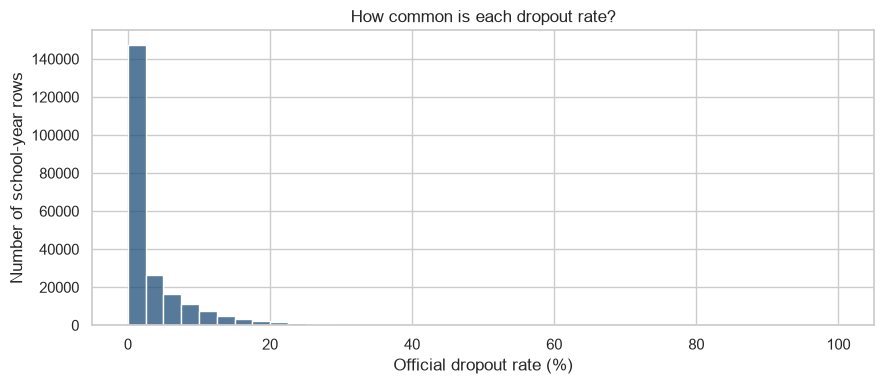

Share of rows with 0% dropout: 0.46108552879897335
Share of rows with dropout >= 5%: 0.22824701708266912


In [4]:
display(df['target_dropout_rate'].describe().rename('Dropout rate (%)'))
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df['target_dropout_rate'], bins=40, ax=ax, color='#1f4e79')
ax.set_title('How common is each dropout rate?')
ax.set_xlabel('Official dropout rate (%)')
ax.set_ylabel('Number of school-year rows')
plt.tight_layout()
plt.show()
print('Share of rows with 0% dropout:', float((df['target_dropout_rate'] == 0).mean()))
print('Share of rows with dropout >= 5%:', float((df['target_dropout_rate'] >= 5).mean()))


### How to read this chart
- **X-axis:** dropout rate in percent (0-100 scale, usually concentrated near 0).
- **Y-axis:** how many school-year observations fall in that bin.
- A tall bar at 0% means many schools reported **no dropout** that year.

### Insight for Ensino Medio
Dropout is a **rare / skewed** school outcome. That is normal, but it has a sharp practical consequence covered in `docs/validity_and_english_revision.md`: because so many schools sit at exactly 0%, the MAE of a model that always predicts the *average* dropout rate is a surprisingly strong baseline - and the first version of this project's models did not beat it. Judge any model here against that baseline, not in isolation.


## 2. Data quality (missing values)


In [5]:
miss = missingness_table(df).head(15).rename(columns={
    'pct_missing': 'Share missing',
    'n_missing': 'Count missing',
    'dtype': 'Data type',
})
display(miss)


,Share missing,Count missing,Data type
dropout_rate_trend,0.280,62987,float64
dropout_rate_lag2,0.277,62377,float64
dropout_rate_lag1,0.142,32080,float64
approval_rate_lag1,0.142,32080,float64
failure_rate_lag1,0.142,32080,float64
dropout_rate_3yr_avg,0.139,31357,float64
overage_enrollment_15_17,0.128,28917,float64
overage_enrollment_18_plus,0.128,28917,float64
municipal_dropout_rate_lag1,0.123,27717,float64
state_dropout_rate_lag1,0.123,27715,float64


### How to read this table
- **Share missing = 0.000** means the column is fully filled in this mart.
- History columns (`dropout_rate_lag1`, etc.) are expected to have some missingness - that is a school's first year in the panel, not a data-quality defect. `has_history` distinguishes the two cases explicitly (0 = no track record yet).

### Insight
For modeling we already kept every row with a non-null official dropout rate. If a *feature* is heavily missing, the pipeline's imputer fills it (median for numeric columns) rather than dropping the row - dropping would have silently discarded exactly the schools with the least track record (see `src/data_loader.py`).


## 3. Where is dropout higher? (by state / UF)


,State (UF),School-year rows,Mean dropout rate (%),Median dropout rate (%)
0,AC,1539,8.425,4.100
3,AP,1132,7.023,3.600
21,RR,1250,7.009,4.200
19,RN,3654,6.538,2.000
22,RS,11886,5.749,3.400
4,BA,11951,5.334,2.500
13,PA,7052,5.229,0.500
2,AM,3798,5.115,1.400
9,MA,8038,5.084,1.800
16,PI,5100,4.953,1.500


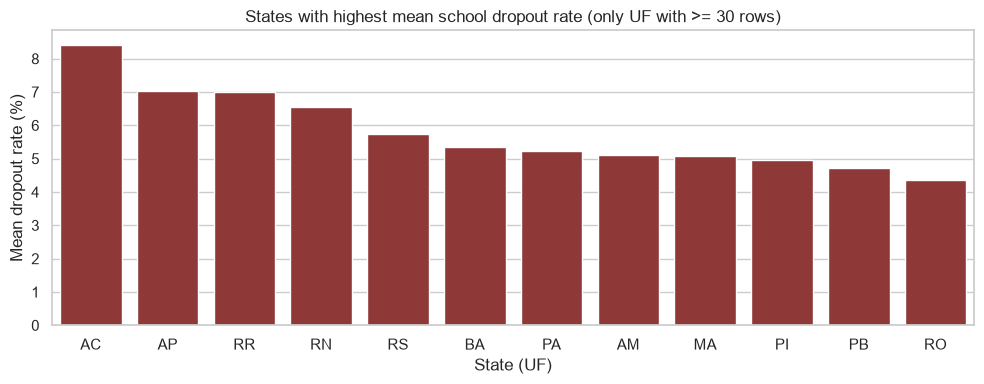

In [6]:
g = summary_by_state(df, min_n=30).rename(columns={
    'state_code': 'State (UF)',
    'n': 'School-year rows',
    'mean_dropout_rate': 'Mean dropout rate (%)',
    'median_dropout_rate': 'Median dropout rate (%)',
})
display(g.head(15))
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=g.head(12), x='State (UF)', y='Mean dropout rate (%)', ax=ax, color='#9c2a2a')
ax.set_title('States with highest mean school dropout rate (only UF with >= 30 rows)')
ax.set_xlabel('State (UF)')
ax.set_ylabel('Mean dropout rate (%)')
plt.tight_layout()
plt.show()


### How to read this chart
- Each bar is a **state (UF)**.
- Height = average school dropout rate among schools of **Ensino Medio** in that state (with enough sample size).
- We require **n >= 30** so tiny samples do not create fake "worst state" headlines.

### Insight
Use this as a **map of attention**, not as a final ranking for newspapers:
- Different states have different networks (more municipal vs state schools).
- Coverage and school size differ.
- Still, persistently high bars suggest where network managers may want deeper local diagnostics. The trained model also uses a *lagged* version of this exact signal (`state_dropout_rate_lag1`) as a feature - see section 4.


## 4. Does a school's own dropout history predict this year's rate?


,Correlation with same-year dropout rate
"Approval rate, prior year",-0.384
"Failure rate, prior year",0.181
"State's dropout rate, prior year",0.220
"Municipality's dropout rate, prior year",0.266
"Dropout rate, 2 years prior",0.329
"Dropout rate, prior year",0.432
"Dropout rate, 3-year trailing avg",0.482


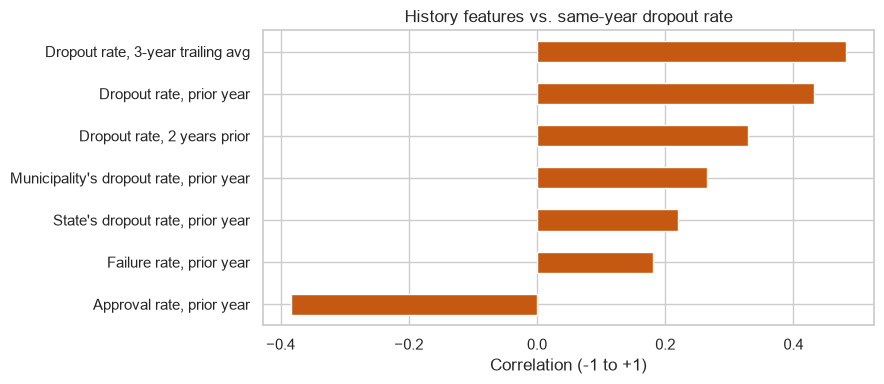

Share of rows with at least one prior year on record: 0.8575482129139117


In [7]:
hist_cols = [c for c in ['dropout_rate_lag1', 'dropout_rate_lag2', 'dropout_rate_3yr_avg',
                          'approval_rate_lag1', 'failure_rate_lag1',
                          'municipal_dropout_rate_lag1', 'state_dropout_rate_lag1']
             if c in df.columns]
corr = df[hist_cols + ['target_dropout_rate']].corr(numeric_only=True)['target_dropout_rate'].drop('target_dropout_rate')
corr_named = corr.rename(index=FEATURE_LABELS).sort_values()
display(corr_named.rename('Correlation with same-year dropout rate').to_frame())
ax = corr_named.plot(kind='barh', figsize=(9, 4), color='#c65911')
ax.set_title('History features vs. same-year dropout rate')
ax.set_xlabel('Correlation (-1 to +1)')
plt.tight_layout()
plt.show()
print('Share of rows with at least one prior year on record:', float(df['has_history'].mean()))


### How to read this chart
Same idea as the state chart above, but for the school's **own trailing history** instead of a same-year snapshot.

### Insight for Ensino Medio
This is the single biggest change in v3.0.0 of this project (see `docs/validity_and_english_revision.md`): earlier versions never computed these columns at all, so the model never got to use a school's own track record. `dropout_rate_lag1` is typically the single strongest feature in the entire dataset - stronger than any Census infrastructure variable - which matches the intuition that dropout is a slow-moving, largely persistent school-level condition, not something that appears out of nowhere each year.


## 5. Which school traits move with dropout? (simple correlations)


,Correlation with dropout rate
Has sports court (1=yes),-0.135
Has internet (1=yes),-0.127
Has computer lab (1=yes),-0.034
Has library (1=yes),-0.026
Number of teachers,-0.024
Rural school (1=yes),0.103
Enrollment (this level),0.129
Students per teacher,0.147
Public network (1=yes),0.293


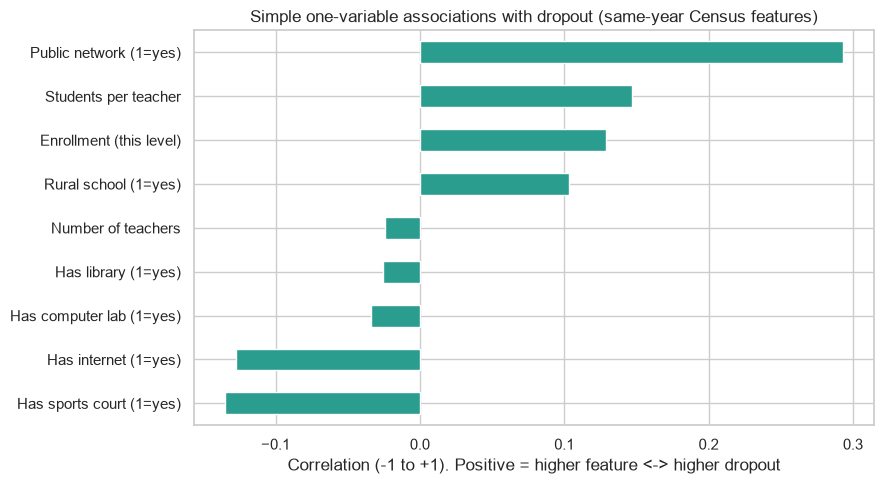

In [8]:
feat = ['is_rural', 'is_public', 'has_internet', 'has_computer_lab', 'has_sports_court',
        'has_library', 'enrollment_level', 'teacher_count_basic_ed']
feat = [c for c in feat if c in df.columns]
tmp = df[feat + ['target_dropout_rate']].copy()
if 'teacher_count_basic_ed' in tmp.columns and 'enrollment_level' in tmp.columns:
    tmp['student_teacher_ratio'] = tmp['enrollment_level'] / tmp['teacher_count_basic_ed'].replace({0: pd.NA})
    feat = feat + ['student_teacher_ratio']
corr = tmp[feat + ['target_dropout_rate']].corr(numeric_only=True)['target_dropout_rate'].drop('target_dropout_rate')
corr_named = corr.rename(index=FEATURE_LABELS).sort_values()
display(corr_named.rename('Correlation with dropout rate').to_frame())
ax = corr_named.plot(kind='barh', figsize=(9, 5), color='#2a9d8f')
ax.set_title('Simple one-variable associations with dropout (same-year Census features)')
ax.set_xlabel('Correlation (-1 to +1). Positive = higher feature <-> higher dropout')
plt.tight_layout()
plt.show()


### How to read this chart
- Each bar is **one school characteristic**.
- Axis goes from -1 to +1:
  - **Positive** correlation: when the feature is higher/true, dropout tends to be **higher**.
  - **Negative** correlation: when the feature is higher/true, dropout tends to be **lower**.
- Example readings:
  - `Rural school (1=yes)` positive means rural schools show higher dropout **on average** in this table.
  - `Has internet (1=yes)` negative means schools with internet show lower dropout **on average**.

### Critical caveats (please keep)
1. Correlation is **not causation** (internet does not automatically "cause" retention).
2. This is **univariate** (one variable at a time). The ML model can reorder importance when variables are combined, and typically the history features from section 4 dominate all of these once combined - see `models/medio/figures/global_importance_top.csv`.
3. Compare with the trained model's actual feature importances in section 6.

### Insight for Ensino Medio
Write down the 3 strongest bars (positive and negative) here, then compare them against section 4's history features and section 6's model importances. Same-year Census features are real, legitimate predictors (see `docs/data_card.md` for why they are not leakage) - they are just weaker than the school's own history.


## 6. Compare with the trained model's actual drivers


,feature_label,importance
0,"Dropout rate, 3-year trailing avg",0.335
1,Share of over-age students,0.073
2,"State's dropout rate, prior year",0.061
3,"Dropout rate, prior year",0.049
4,Average class size,0.035
5,Students per teacher,0.034
6,Basic-ed enrollment (total),0.032
7,"Approval rate, prior year",0.030
8,"Failure rate, prior year",0.029
9,Number of teachers,0.027


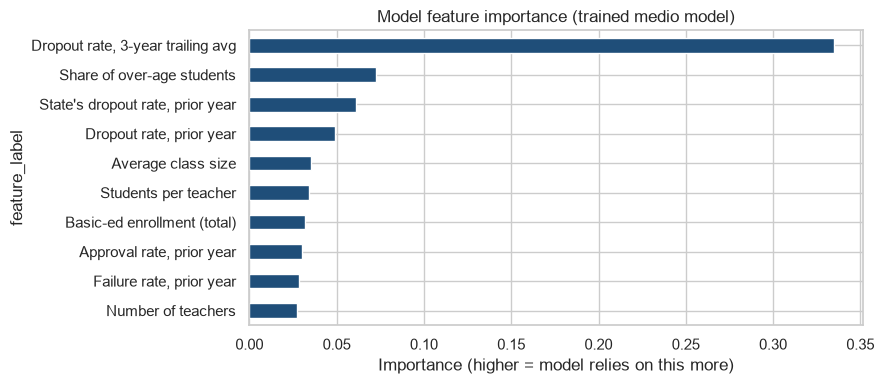

In [9]:
imp_path = Path(ROOT) / 'models' / 'medio' / 'figures' / 'global_importance_top.csv'
try:
    imp = pd.read_csv(imp_path)
    imp['feature_label'] = imp['feature'].map(FEATURE_LABELS).fillna(imp['feature'])
    display(imp[['feature_label', 'importance']].head(12))
    ax = imp.head(10).set_index('feature_label')['importance'].plot(kind='barh', color='#1f4e79', figsize=(9, 4))
    ax.invert_yaxis()
    ax.set_title('Model feature importance (trained medio model)')
    ax.set_xlabel('Importance (higher = model relies on this more)')
    plt.tight_layout(); plt.show()
except FileNotFoundError:
    print('Train first: python -m src.train --level medio')


### How to read model importance
Unlike correlation, this answers: **"When the trained model predicts dropout, which inputs move the prediction most?"**

### Insight
If correlation and model importance **agree**, the narrative is robust.
If they **disagree**, prefer the model list for triage explanations, but still show both transparently - disagreement often means confounding (variables overlapping, e.g. rural schools also tending to have lower enrollment).

### Closing takeaway (Ensino Medio)
1. Outcome = official school dropout %, skewed toward zero.
2. A school's **own dropout history** is the strongest available signal - new in v3.0.0.
3. Geography (state, and its own lagged average) highlights uneven and locally-correlated risk.
4. Structural/staffing traits associate with risk - useful for prioritization, not blame.
5. This notebook alone does **not** authorize student-level interventions, and no model here should be trusted until it is checked against a trivial baseline (see `docs/validity_and_english_revision.md`).
